# Causal Detection of Wellbeing Problems in Gamers

This notebook builds a **cause → issue** wellbeing analysis pipeline:
- Defines issue outcomes (sleep, social isolation, productivity, emotional, dysregulation).
- Groups predictors into actionable causes, context/confounders, and optional mediators.
- Trains and compares multiple models from scratch.
- Produces global and personalized contributor analysis with intervention what-if scenarios.

Design goal: outputs that are both **predictive** and **actionable** while avoiding circular definitions where possible.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
DATA_FILENAME = "Gaming and Mental Health.csv"
_candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for _root in _candidate_roots:
    _p = _root / "data" / DATA_FILENAME
    if _p.exists():
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError(
        f"Could not locate dataset '{DATA_FILENAME}' in expected data/ folders from cwd={Path.cwd()}"
    )

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print(f"Using dataset: {DATA_PATH.resolve()}")


Using dataset: /home/nate/Projects/Dataquest26/data/Gaming and Mental Health.csv


## 1) Load data and validate schema

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw_df.shape}")
raw_df.head(3)


Raw shape: (1000, 27)


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,NaN,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,NaN,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe


In [3]:
EXPECTED_COLUMNS = {
    "record_id",
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "sleep_hours",
    "sleep_quality",
    "sleep_disruption_frequency",
    "academic_work_performance",
    "grades_gpa",
    "work_productivity_score",
    "mood_state",
    "mood_swing_frequency",
    "withdrawal_symptoms",
    "loss_of_other_interests",
    "continued_despite_problems",
    "eye_strain",
    "back_neck_pain",
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "gaming_addiction_risk_level",
}

actual_columns = set(raw_df.columns)
missing_cols = sorted(EXPECTED_COLUMNS - actual_columns)
extra_cols = sorted(actual_columns - EXPECTED_COLUMNS)

print(f"Missing expected columns: {missing_cols}")
print(f"Unexpected extra columns: {extra_cols}")
assert not missing_cols, "Dataset schema mismatch: expected columns are missing."

print("\nData types:")
print(raw_df.dtypes)

dup_record_ids = raw_df.duplicated(subset=["record_id"]).sum()
print(f"\nDuplicate record_id count: {dup_record_ids}")

missing_pct_raw = (raw_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct_raw.head(10)


Missing expected columns: []
Unexpected extra columns: []

Data types:
record_id                               str
age                                   int64
gender                                  str
daily_gaming_hours                  float64
game_genre                              str
primary_game                            str
gaming_platform                         str
sleep_hours                         float64
sleep_quality                           str
sleep_disruption_frequency              str
academic_work_performance               str
grades_gpa                          float64
work_productivity_score             float64
mood_state                              str
mood_swing_frequency                    str
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exerc

work_productivity_score    32.6
grades_gpa                 24.6
record_id                   0.0
daily_gaming_hours          0.0
game_genre                  0.0
primary_game                0.0
gaming_platform             0.0
sleep_hours                 0.0
sleep_quality               0.0
age                         0.0
dtype: float64

## 2) Cleaning and data quality safeguards

In [4]:
df = raw_df.copy()

# Normalize string columns: trim and convert blank-like tokens to missing.
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype("string").str.strip()
    df[c] = df[c].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "NA": pd.NA})

# Remove duplicate records by ID (first occurrence kept).
if "record_id" in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset=["record_id"], keep="first").reset_index(drop=True)
    print(f"Dropped duplicate rows by record_id: {before - len(df)}")

numeric_cols = [
    "age",
    "daily_gaming_hours",
    "sleep_hours",
    "grades_gpa",
    "work_productivity_score",
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Plausible-value clipping to reduce impact of obvious data-entry outliers.
valid_ranges = {
    "age": (10, 80),
    "daily_gaming_hours": (0, 24),
    "sleep_hours": (0, 24),
    "grades_gpa": (0, 4.3),
    "work_productivity_score": (1, 10),
    "weight_change_kg": (-30, 30),
    "exercise_hours_weekly": (0, 40),
    "social_isolation_score": (1, 10),
    "face_to_face_social_hours_weekly": (0, 80),
    "monthly_game_spending_usd": (0, 2000),
    "years_gaming": (0, 70),
}

for c, (lo, hi) in valid_ranges.items():
    df[c] = df[c].clip(lower=lo, upper=hi)

# Median imputation for numeric features.
for c in numeric_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

# Mode imputation for categorical features.
cat_cols = [c for c in df.columns if c not in numeric_cols]
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print(f"Cleaned shape: {df.shape}")
print("Remaining missing values:", int(df.isna().sum().sum()))
df.head(3)


Dropped duplicate rows by record_id: 0
Cleaned shape: (1000, 27)
Remaining missing values: 0


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,5.0,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,2.53,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe


In [5]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
quality_report.sort_values("missing_pct", ascending=False).head(15)


,dtype,missing_count,missing_pct
record_id,string,0,0.0
age,int64,0,0.0
gender,string,0,0.0
daily_gaming_hours,float64,0,0.0
game_genre,string,0,0.0
primary_game,string,0,0.0
gaming_platform,string,0,0.0
sleep_hours,float64,0,0.0
sleep_quality,string,0,0.0
sleep_disruption_frequency,string,0,0.0


## 3) Cause/issue taxonomy and target engineering

In [6]:
# --- Cause/issue taxonomy ---
# Actionable causes = knobs a user can realistically change.
actionable_cause_features = [
    "daily_gaming_hours",
    "monthly_game_spending_usd",
    "exercise_hours_weekly",
    "game_genre",
    "primary_game",
    "gaming_platform",
]

# Context/confounders = background factors to adjust for.
context_confounders = [
    "age",
    "gender",
    "years_gaming",
]

# Mediators = symptom-like process variables (optional for augmented prediction only).
mediator_features = [
    "sleep_hours",
    "sleep_quality",
    "sleep_disruption_frequency",
    "mood_state",
    "mood_swing_frequency",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "academic_work_performance",
    "work_productivity_score",
]

# Core predictor set used for intervention-oriented recommendations.
feature_cols = actionable_cause_features + context_confounders

# --- Composite overall wellbeing target (kept for continuity) ---
negative_moods = {"Depressed", "Anxious", "Withdrawn"}
poor_sleep_levels = {"Very Poor", "Insomnia"}
poor_perf_levels = {"Poor", "Failing"}

df["adverse_mood"] = df["mood_state"].isin(negative_moods).astype(int)
df["adverse_sleep"] = df["sleep_quality"].isin(poor_sleep_levels).astype(int)
df["high_isolation"] = (df["social_isolation_score"] >= 7).astype(int)
df["low_social_contact"] = (df["face_to_face_social_hours_weekly"] <= 3).astype(int)
df["poor_performance"] = df["academic_work_performance"].isin(poor_perf_levels).astype(int)

df["wellbeing_problem_score"] = (
    df["adverse_mood"]
    + df["adverse_sleep"]
    + df["high_isolation"]
    + df["low_social_contact"]
    + df["poor_performance"]
)
df["wellbeing_problem"] = (df["wellbeing_problem_score"] >= 2).astype(int)

# --- Issue-specific targets with non-circular intent ---
# For each issue, we track source columns used to define the target so they can be excluded
# from predictors in issue-specific models.
issue_target_specs = {
    "social_isolation_problem": {
        "definition_cols": ["social_isolation_score", "face_to_face_social_hours_weekly"],
        "target": (
            (df["social_isolation_score"] >= 7)
            | (df["face_to_face_social_hours_weekly"] <= 5)
        ).astype(int),
    },
    "productivity_problem": {
        "definition_cols": ["academic_work_performance", "work_productivity_score"],
        "target": (
            (df["academic_work_performance"].isin(["Poor", "Failing"]))
            | (df["work_productivity_score"] <= 4)
        ).astype(int),
    },
    "sleep_problem": {
        "definition_cols": ["sleep_quality", "sleep_disruption_frequency"],
        # Non-circular choice per user preference:
        # do not use sleep_hours to define sleep target.
        "target": (
            (df["sleep_quality"].isin(["Poor", "Very Poor", "Insomnia"]))
            | (df["sleep_disruption_frequency"].isin(["Often", "Always"]))
        ).astype(int),
    },
    "emotional_problem": {
        "definition_cols": ["mood_state"],
        "target": df["mood_state"].isin(["Depressed", "Anxious", "Withdrawn"]).astype(int),
    },
    "dysregulation_problem": {
        "definition_cols": ["mood_swing_frequency", "continued_despite_problems"],
        "target": (
            (df["mood_swing_frequency"].isin(["Often", "Daily"]))
            | (df["continued_despite_problems"] == True)
        ).astype(int),
    },
}

issue_targets = pd.DataFrame({k: v["target"] for k, v in issue_target_specs.items()})

# Reliability threshold used for interpretive flags.
ISSUE_RELIABILITY_ROC_THRESHOLD = 0.65

print("Cause/issue taxonomy defined.")
print(f"Actionable cause features: {actionable_cause_features}")
print(f"Context/confounders: {context_confounders}")
print(f"Mediator features available: {len(mediator_features)}")

target_rate = df["wellbeing_problem"].mean()
print(f"\nOverall wellbeing_problem prevalence: {target_rate:.3f} ({target_rate*100:.1f}%)")
print(df["wellbeing_problem"].value_counts())

issue_prevalence_df = (
    issue_targets.mean().rename("prevalence").reset_index().rename(columns={"index": "issue"})
    .sort_values("prevalence", ascending=False)
)
issue_prevalence_df["prevalence_pct"] = (100 * issue_prevalence_df["prevalence"]).round(1)
print("\nIssue prevalence (sanity check):")
issue_prevalence_df

Cause/issue taxonomy defined.
Actionable cause features: ['daily_gaming_hours', 'monthly_game_spending_usd', 'exercise_hours_weekly', 'game_genre', 'primary_game', 'gaming_platform']
Context/confounders: ['age', 'gender', 'years_gaming']
Mediator features available: 9

Overall wellbeing_problem prevalence: 0.271 (27.1%)
wellbeing_problem
0    729
1    271
Name: count, dtype: int64

Issue prevalence (sanity check):


,issue,prevalence,prevalence_pct
2,sleep_problem,0.705,70.5
4,dysregulation_problem,0.486,48.6
1,productivity_problem,0.458,45.8
3,emotional_problem,0.297,29.7
0,social_isolation_problem,0.264,26.4


## 4) Visualization: quality + risk patterns

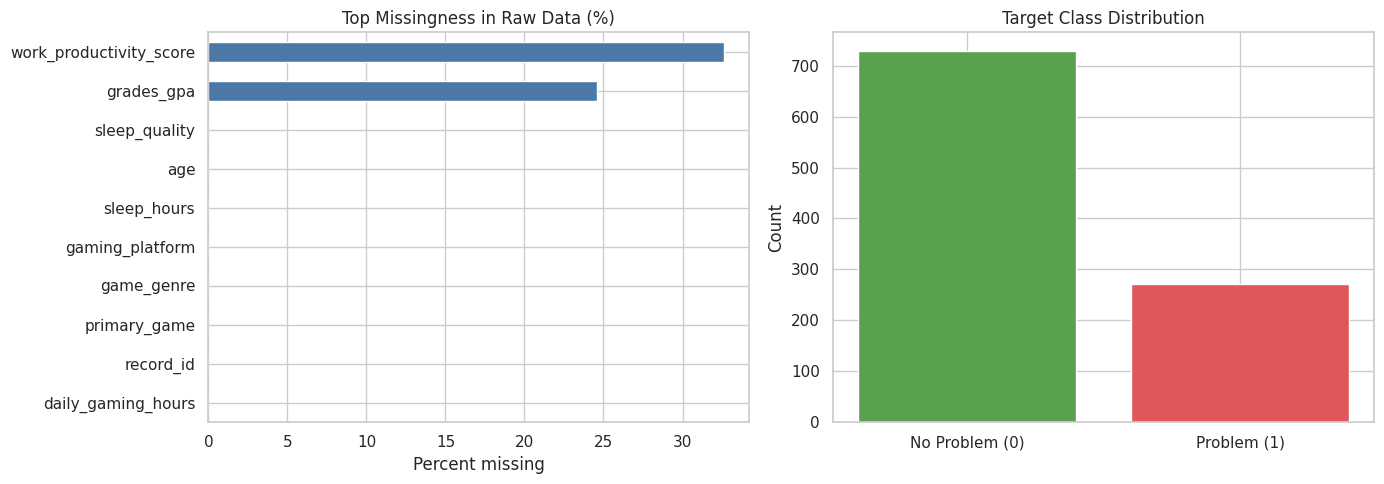

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missingness before cleaning.
missing_top = (raw_df.isna().mean() * 100).sort_values(ascending=False).head(10)
missing_top.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top Missingness in Raw Data (%)")
axes[0].set_xlabel("Percent missing")

# Target distribution.
target_counts = df["wellbeing_problem"].value_counts().sort_index()
axes[1].bar(["No Problem (0)", "Problem (1)"], target_counts.values, color=["#59A14F", "#E15759"])
axes[1].set_title("Target Class Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


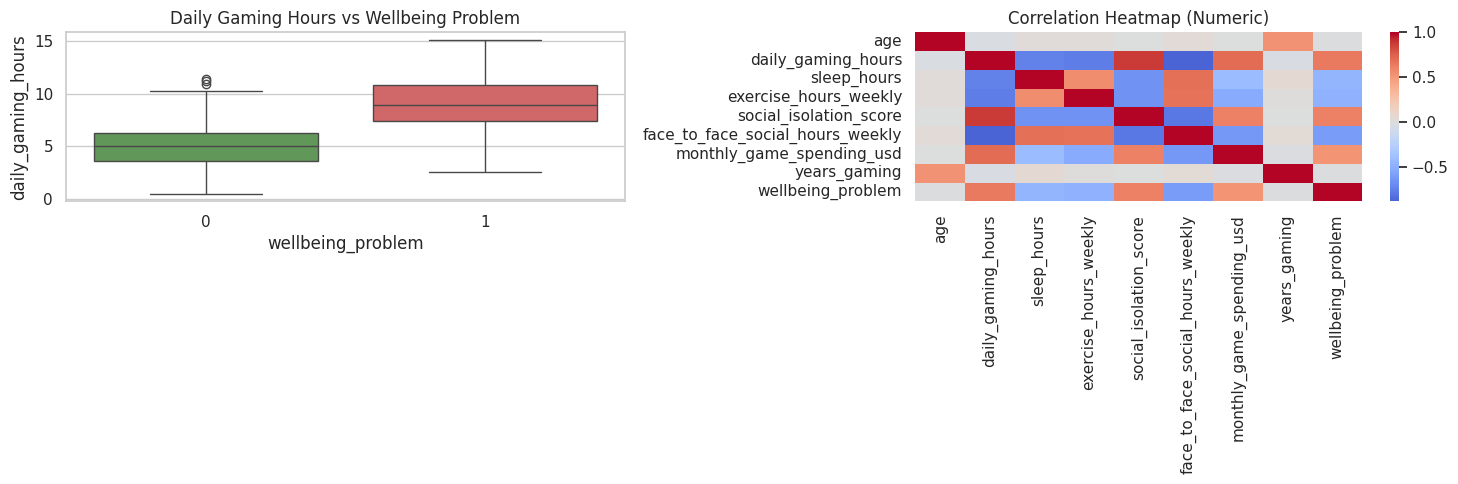

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=df,
    x="wellbeing_problem",
    y="daily_gaming_hours",
    ax=axes[0],
    palette=["#59A14F", "#E15759"],
)
axes[0].set_title("Daily Gaming Hours vs Wellbeing Problem")
axes[0].set_xlabel("wellbeing_problem")

corr_cols = [
    "age",
    "daily_gaming_hours",
    "sleep_hours",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "wellbeing_problem",
]

corr = df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=axes[1])
axes[1].set_title("Correlation Heatmap (Numeric)")

plt.tight_layout()
plt.show()


## 5) Train multiple predictive models

In [9]:
# Cause-core predictors only (actionable + context confounders).
# Defined earlier in taxonomy section.
target_col = "wellbeing_problem"

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y,
)

num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_features,
        ),
    ]
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_SEED),
}

# Optional XGBoost model if available.
xgb_err = None
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        n_jobs=4,
    )
except Exception as exc:
    xgb_err = str(exc)
    print(f"XGBoost skipped: {xgb_err}")

trained_pipelines = {}
results = []
preds = {}
probas = {}
reports = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    trained_pipelines[model_name] = pipe
    preds[model_name] = y_pred
    probas[model_name] = y_proba
    reports[model_name] = classification_report(y_test, y_pred, output_dict=True)

    metrics_row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }
    results.append(metrics_row)

results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.824,0.666667,0.705882,0.685714,0.900291
1,RandomForest,0.796,0.600000,0.750000,0.666667,0.898190
2,GradientBoosting,0.812,0.643836,0.691176,0.666667,0.897786
3,LogisticRegression,0.772,0.556701,0.794118,0.654545,0.888090


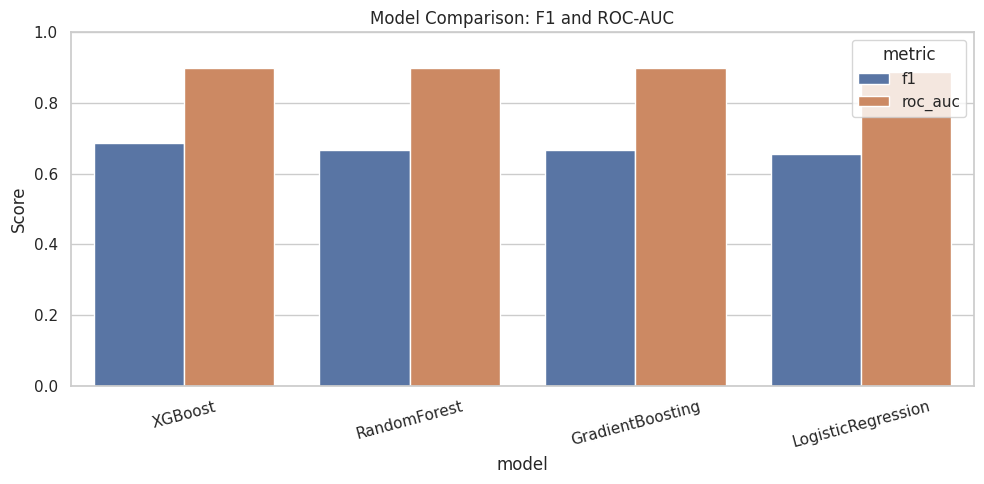

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.melt(id_vars="model", value_vars=["f1", "roc_auc"], var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison: F1 and ROC-AUC")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Best model by F1: XGBoost
{'model': 'XGBoost', 'accuracy': 0.824, 'precision': 0.6666666666666666, 'recall': 0.7058823529411765, 'f1': 0.6857142857142857, 'roc_auc': 0.9002908855850033}


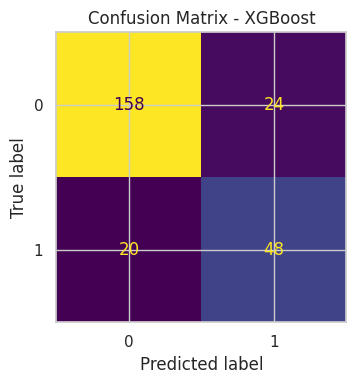

In [11]:
best_model_name = results_df.iloc[0]["model"]
best_pipe = trained_pipelines[best_model_name]

print(f"Best model by F1: {best_model_name}")
print(results_df.iloc[0].to_dict())

cm = confusion_matrix(y_test, preds[best_model_name])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


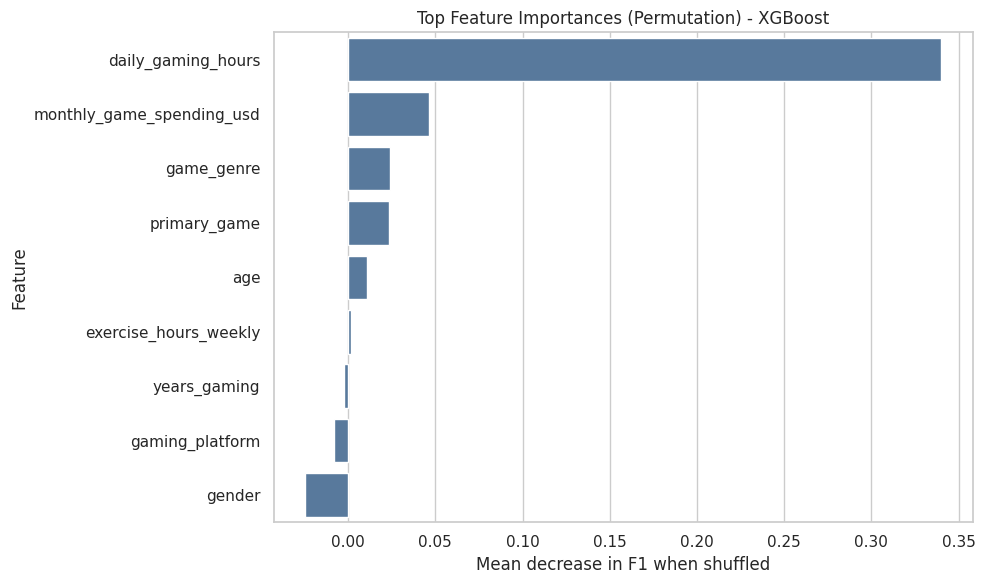

,feature,importance
0,daily_gaming_hours,0.339767
1,monthly_game_spending_usd,0.046381
3,game_genre,0.023862
4,primary_game,0.023317
6,age,0.010760
2,exercise_hours_weekly,0.001594
8,years_gaming,-0.002623
5,gaming_platform,-0.007843
7,gender,-0.024567


In [12]:
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring="f1",
    n_jobs=-1,
)

# For a full pipeline, permutation importance aligns with the original input columns.
feature_names = X_test.columns.to_list()
perm_df = (
    pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=perm_df, y="feature", x="importance", ax=ax, color="#4C78A8")
ax.set_title(f"Top Feature Importances (Permutation) - {best_model_name}")
ax.set_xlabel("Mean decrease in F1 when shuffled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

perm_df.head(10)


## 6) Causal detection: effect of heavy gaming on wellbeing risk

In [13]:
# Treatment definition: heavy gaming = top quartile daily gaming hours.
treatment_threshold = df["daily_gaming_hours"].quantile(0.75)
df["heavy_gaming"] = (df["daily_gaming_hours"] >= treatment_threshold).astype(int)

Y = df["wellbeing_problem"].astype(int).to_numpy()
T = df["heavy_gaming"].astype(int).to_numpy()

causal_features = [
    "age",
    "gender",
    "years_gaming",
    "monthly_game_spending_usd",
    "exercise_hours_weekly",
    "game_genre",
    "gaming_platform",
]

X_causal = df[causal_features].copy()
num_causal = X_causal.select_dtypes(include=["number"]).columns.tolist()
cat_causal = [c for c in X_causal.columns if c not in num_causal]

preprocess_causal = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            num_causal,
        ),
        (
            "cat",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
            cat_causal,
        ),
    ]
)

Xc = preprocess_causal.fit_transform(X_causal)

# Propensity score model e(X) = P(T=1|X).
propensity_model = LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_SEED)
propensity_model.fit(Xc, T)
e_hat = propensity_model.predict_proba(Xc)[:, 1]
e_hat = np.clip(e_hat, 0.02, 0.98)

# Outcome models m1(X), m0(X).
outcome_model_treated = GradientBoostingClassifier(random_state=RANDOM_SEED)
outcome_model_control = GradientBoostingClassifier(random_state=RANDOM_SEED)
outcome_model_treated.fit(Xc[T == 1], Y[T == 1])
outcome_model_control.fit(Xc[T == 0], Y[T == 0])

m1_hat = outcome_model_treated.predict_proba(Xc)[:, 1]
m0_hat = outcome_model_control.predict_proba(Xc)[:, 1]

# Method 1: Naive difference in means.
naive_ate = Y[T == 1].mean() - Y[T == 0].mean()

# Method 2: IPTW estimate.
iptw_ate = np.mean(T * Y / e_hat) - np.mean((1 - T) * Y / (1 - e_hat))

# Method 3: Doubly robust (AIPW) estimate.
aipw_scores = (m1_hat - m0_hat) + (T * (Y - m1_hat) / e_hat) - ((1 - T) * (Y - m0_hat) / (1 - e_hat))
aipw_ate = float(np.mean(aipw_scores))
aipw_se = float(np.std(aipw_scores, ddof=1) / np.sqrt(len(aipw_scores)))
aipw_ci = (aipw_ate - 1.96 * aipw_se, aipw_ate + 1.96 * aipw_se)

causal_summary = pd.DataFrame(
    {
        "method": ["Naive Difference", "IPTW", "AIPW (Doubly Robust)"],
        "estimated_ate": [naive_ate, iptw_ate, aipw_ate],
    }
)

print(f"Heavy gaming threshold (75th pct): {treatment_threshold:.2f} hours/day")
print(f"Treatment prevalence: {T.mean():.3f}")
print(f"AIPW 95% CI: ({aipw_ci[0]:.4f}, {aipw_ci[1]:.4f})")
causal_summary


Heavy gaming threshold (75th pct): 8.03 hours/day
Treatment prevalence: 0.250
AIPW 95% CI: (0.1251, 0.2017)


,method,estimated_ate
0,Naive Difference,0.577333
1,IPTW,0.098386
2,AIPW (Doubly Robust),0.163396


In [14]:
# Simple subgroup heterogeneity checks using the AIPW pseudo-outcome.
subgroup_rows = []

df["age_band"] = pd.cut(df["age"], bins=[0, 18, 25, 35, 100], labels=["<=18", "19-25", "26-35", "36+"], include_lowest=True)

for group_col in ["gender", "age_band"]:
    for g in sorted(df[group_col].dropna().astype(str).unique()):
        idx = df[group_col].astype(str) == g
        n = int(idx.sum())
        if n < 30:
            continue
        est = float(np.mean(aipw_scores[idx]))
        se = float(np.std(aipw_scores[idx], ddof=1) / np.sqrt(n)) if n > 1 else np.nan
        subgroup_rows.append(
            {
                "group_type": group_col,
                "group": g,
                "n": n,
                "aipw_ate": est,
                "ci_low": est - 1.96 * se,
                "ci_high": est + 1.96 * se,
            }
        )

subgroup_df = pd.DataFrame(subgroup_rows).sort_values(["group_type", "aipw_ate"], ascending=[True, False])
subgroup_df.head(20)


,group_type,group,n,aipw_ate,ci_low,ci_high
3,age_band,26-35,124,0.230843,0.143738,0.317948
2,age_band,19-25,550,0.176673,0.122406,0.230940
4,age_band,<=18,326,0.115341,0.049590,0.181092
1,gender,Male,647,0.174942,0.124834,0.225051
0,gender,Female,331,0.162035,0.102565,0.221506


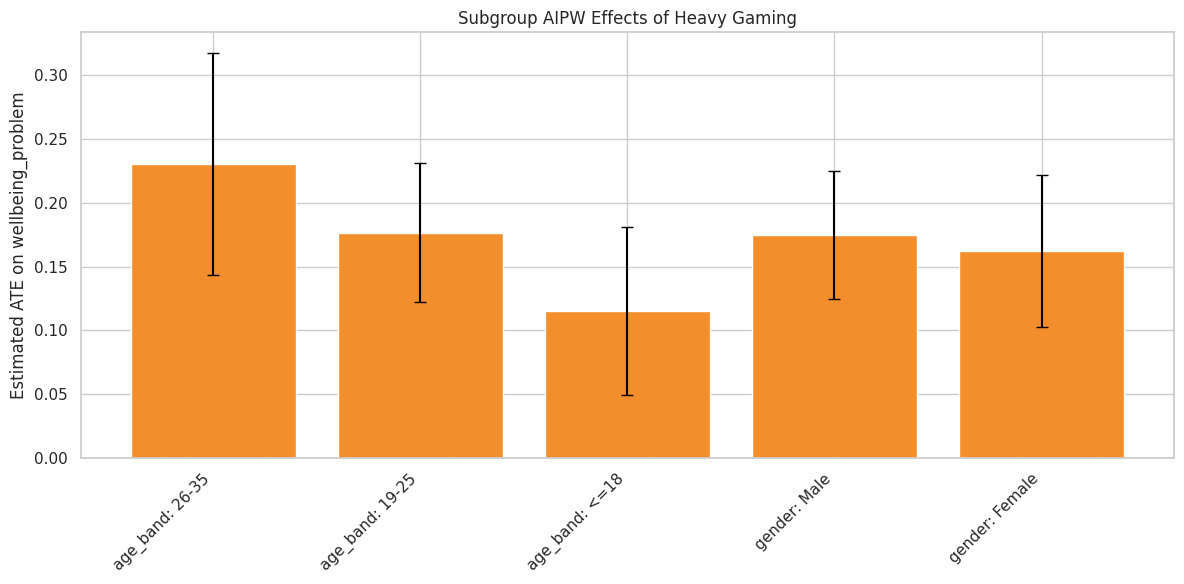

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = subgroup_df.copy()
plot_df["label"] = plot_df["group_type"] + ": " + plot_df["group"]

ax.bar(plot_df["label"], plot_df["aipw_ate"], color="#F28E2B")
ax.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["aipw_ate"],
    yerr=[plot_df["aipw_ate"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["aipw_ate"]],
    fmt="none",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylabel("Estimated ATE on wellbeing_problem")
ax.set_title("Subgroup AIPW Effects of Heavy Gaming")
plt.tight_layout()
plt.show()


## 8) Personalized risk report + what-if simulator

This section turns the trained best model into a **personal analysis tool**:

- Score one user profile for current wellbeing-problem risk.
- Show risk band and profile summary.
- Simulate practical interventions (reduce gaming, increase exercise, reduce spending) and estimate risk deltas.

> Intended for self-monitoring and coaching support, not medical diagnosis.


In [16]:
def risk_band(p: float) -> str:
    if p < 0.20:
        return "Low"
    if p < 0.40:
        return "Moderate"
    if p < 0.60:
        return "High"
    return "Very High"


def score_single_profile(profile: dict, model_pipeline, feature_columns):
    row = {c: profile.get(c, np.nan) for c in feature_columns}
    X_one = pd.DataFrame([row])
    proba = float(model_pipeline.predict_proba(X_one)[:, 1][0])
    pred = int(proba >= 0.5)
    return {
        "predicted_label": pred,
        "risk_probability": proba,
        "risk_band": risk_band(proba),
        "input_profile": row,
    }


def simulate_what_if(base_profile: dict, model_pipeline, feature_columns):
    scenarios = {
        "baseline": {},
        "gaming_hours_-2": {"daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0) - 2.0)},
        "gaming_hours_-4": {"daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0) - 4.0)},
        "exercise_+2h": {"exercise_hours_weekly": base_profile.get("exercise_hours_weekly", 0) + 2.0},
        "spending_-30pct": {"monthly_game_spending_usd": max(0.0, base_profile.get("monthly_game_spending_usd", 0) * 0.7)},
        "combined_healthy_shift": {
            "daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0) - 3.0),
            "exercise_hours_weekly": base_profile.get("exercise_hours_weekly", 0) + 2.0,
            "monthly_game_spending_usd": max(0.0, base_profile.get("monthly_game_spending_usd", 0) * 0.8),
        },
    }

    rows = []
    baseline_prob = None
    for name, updates in scenarios.items():
        profile = dict(base_profile)
        profile.update(updates)
        scored = score_single_profile(profile, model_pipeline, feature_columns)
        p = scored["risk_probability"]
        if name == "baseline":
            baseline_prob = p
        rows.append({
            "scenario": name,
            "risk_probability": p,
            "risk_band": scored["risk_band"],
        })

    out = pd.DataFrame(rows)
    out["delta_vs_baseline"] = out["risk_probability"] - float(out.loc[out["scenario"] == "baseline", "risk_probability"].iloc[0])
    return out.sort_values("risk_probability", ascending=False).reset_index(drop=True)


# Example personal profile (replace values with real user data).
example_profile = {
    "age": 23,
    "gender": "Male",
    "daily_gaming_hours": 9.0,
    "game_genre": "MOBA",
    "primary_game": "League of Legends",
    "gaming_platform": "PC",
    "monthly_game_spending_usd": 110.0,
    "years_gaming": 8.0,
    "exercise_hours_weekly": 1.0,
}

personal_result = score_single_profile(example_profile, best_pipe, feature_cols)
print("Personal risk summary:")
print({
    "predicted_label": personal_result["predicted_label"],
    "risk_probability": round(personal_result["risk_probability"], 4),
    "risk_band": personal_result["risk_band"],
})

what_if_df = simulate_what_if(example_profile, best_pipe, feature_cols)
what_if_df

Personal risk summary:
{'predicted_label': 1, 'risk_probability': 0.7185, 'risk_band': 'Very High'}


,scenario,risk_probability,risk_band,delta_vs_baseline
0,baseline,0.718495,Very High,0.000000
1,exercise_+2h,0.718495,Very High,0.000000
2,gaming_hours_-2,0.494589,High,-0.223906
3,spending_-30pct,0.307661,Moderate,-0.410834
4,gaming_hours_-4,0.014935,Low,-0.703560
5,combined_healthy_shift,0.006499,Low,-0.711996


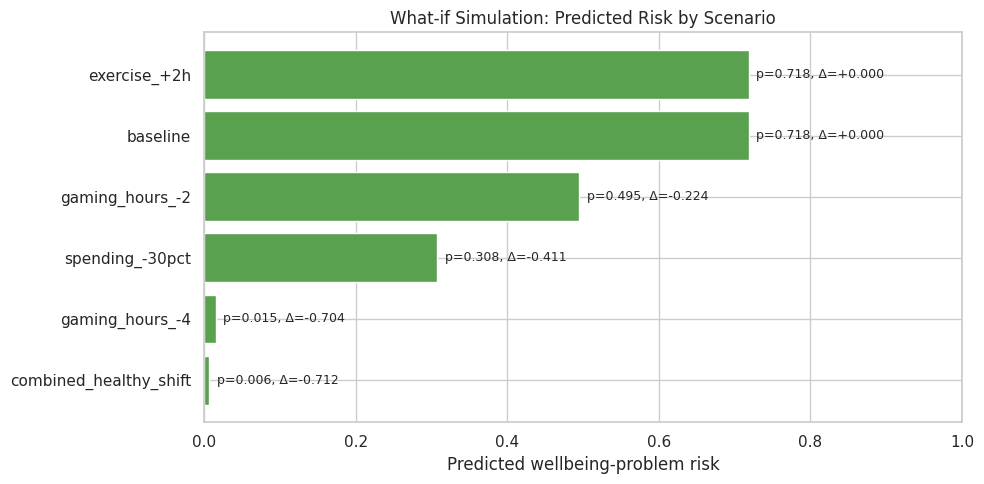

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = what_if_df.sort_values("risk_probability", ascending=True)
colors = ["#E15759" if x > 0 else "#59A14F" for x in plot_df["delta_vs_baseline"]]

ax.barh(plot_df["scenario"], plot_df["risk_probability"], color=colors)
for i, (p, d) in enumerate(zip(plot_df["risk_probability"], plot_df["delta_vs_baseline"])):
    ax.text(min(p + 0.01, 0.96), i, f"p={p:.3f}, Δ={d:+.3f}", va="center", fontsize=9)

ax.set_xlim(0, 1)
ax.set_xlabel("Predicted wellbeing-problem risk")
ax.set_title("What-if Simulation: Predicted Risk by Scenario")
plt.tight_layout()
plt.show()

## 9) Issue models with cause-groups, leakage guards, and dual-track comparison

In [18]:
# Targets already engineered above in issue_targets / issue_target_specs.
# Here we just restate and inspect prevalence for this section.
issue_prevalence_df = (
    issue_targets.mean()
    .rename("prevalence")
    .reset_index()
    .rename(columns={"index": "issue"})
    .sort_values("prevalence", ascending=False)
)
issue_prevalence_df["prevalence_pct"] = (100 * issue_prevalence_df["prevalence"]).round(1)
issue_prevalence_df

,issue,prevalence,prevalence_pct
2,sleep_problem,0.705,70.5
4,dysregulation_problem,0.486,48.6
1,productivity_problem,0.458,45.8
3,emotional_problem,0.297,29.7
0,social_isolation_problem,0.264,26.4


In [19]:
from sklearn.base import clone

issue_model_candidates = {
    "LogisticRegression": LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=450,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_SEED),
}

issue_track_feature_sets = {
    "cause_core": feature_cols,
    "augmented": feature_cols + mediator_features,
}

# Explicit leakage guard: remove definition columns for each issue from candidate features.
leakage_guard_records = []
issue_feature_sets = {}
for issue_name, spec in issue_target_specs.items():
    def_cols = set(spec["definition_cols"])
    issue_feature_sets[issue_name] = {}
    for track_name, base_feats in issue_track_feature_sets.items():
        valid_feats = [f for f in base_feats if f not in def_cols]
        removed = [f for f in base_feats if f in def_cols]
        issue_feature_sets[issue_name][track_name] = valid_feats
        leakage_guard_records.append({
            "issue": issue_name,
            "track": track_name,
            "removed_definition_cols": ", ".join(removed) if removed else "",
            "n_features_after_guard": len(valid_feats),
        })

leakage_guard_df = pd.DataFrame(leakage_guard_records)
print("Leakage guard summary (target-definition columns removed from predictors):")
leakage_guard_df

issue_best_models = {}          # issue -> best cause_core pipeline (used for personalized dashboards)
issue_best_track_models = {}    # issue -> {track -> best pipeline}
issue_eval_cache = {}           # issue -> eval cache for best cause_core model
issue_eval_track_cache = {}     # issue -> track -> eval cache
issue_model_rows = []

for issue_name in issue_targets.columns:
    y_issue = issue_targets[issue_name].astype(int)
    if y_issue.nunique() < 2:
        continue

    issue_best_track_models[issue_name] = {}
    issue_eval_track_cache[issue_name] = {}

    for track_name, feats in issue_feature_sets[issue_name].items():
        X_issue = df[feats].copy()

        X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
            X_issue,
            y_issue,
            test_size=0.25,
            random_state=RANDOM_SEED,
            stratify=y_issue,
        )

        num_i = X_issue.select_dtypes(include=["number"]).columns.tolist()
        cat_i = [c for c in X_issue.columns if c not in num_i]

        preprocess_i = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                    num_i,
                ),
                (
                    "cat",
                    Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
                    cat_i,
                ),
            ]
        )

        best_pipe_i = None
        best_sort_i = (-1.0, -1.0)
        best_pred_i = None
        best_proba_i = None
        best_test_i = None
        best_model_name = None

        for model_name, model_obj in issue_model_candidates.items():
            pipe_i = Pipeline(steps=[("preprocess", clone(preprocess_i)), ("model", clone(model_obj))])
            pipe_i.fit(X_train_i, y_train_i)

            pred_i = pipe_i.predict(X_test_i)
            proba_i = pipe_i.predict_proba(X_test_i)[:, 1] if hasattr(pipe_i, "predict_proba") else None

            row = {
                "issue": issue_name,
                "track": track_name,
                "model": model_name,
                "n_features": len(feats),
                "accuracy": accuracy_score(y_test_i, pred_i),
                "precision": precision_score(y_test_i, pred_i, zero_division=0),
                "recall": recall_score(y_test_i, pred_i, zero_division=0),
                "f1": f1_score(y_test_i, pred_i, zero_division=0),
                "roc_auc": roc_auc_score(y_test_i, proba_i) if proba_i is not None else np.nan,
                "positive_rate": float(y_issue.mean()),
            }
            issue_model_rows.append(row)

            sort_key = (row["f1"], row["roc_auc"] if not np.isnan(row["roc_auc"]) else -1.0)
            if sort_key > best_sort_i:
                best_sort_i = sort_key
                best_pipe_i = pipe_i
                best_pred_i = pred_i
                best_proba_i = proba_i
                best_test_i = (X_test_i.copy(), y_test_i.copy())
                best_model_name = model_name

        issue_best_track_models[issue_name][track_name] = best_pipe_i
        issue_eval_track_cache[issue_name][track_name] = {
            "X_test": best_test_i[0],
            "y_test": best_test_i[1],
            "pred": best_pred_i,
            "proba": best_proba_i,
            "best_model_name": best_model_name,
        }

    # Cause-core is the default for interpretability and personalization.
    issue_best_models[issue_name] = issue_best_track_models[issue_name]["cause_core"]
    issue_eval_cache[issue_name] = issue_eval_track_cache[issue_name]["cause_core"]

issue_results_df = pd.DataFrame(issue_model_rows).sort_values(
    ["issue", "track", "f1", "roc_auc"], ascending=[True, True, False, False]
).reset_index(drop=True)

issue_best_df = (
    issue_results_df
    .groupby(["issue", "track"], as_index=False)
    .first()
    .sort_values(["track", "f1"], ascending=[True, False])
)

# Reliability flag based on ROC-AUC.
issue_best_df["reliability_flag"] = np.where(
    issue_best_df["roc_auc"] >= ISSUE_RELIABILITY_ROC_THRESHOLD,
    "reliable",
    "weak",
)

print("Best model per issue and track:")
issue_best_df[["issue", "track", "model", "n_features", "accuracy", "precision", "recall", "f1", "roc_auc", "reliability_flag"]]

Leakage guard summary (target-definition columns removed from predictors):


Best model per issue and track:


,issue,track,model,n_features,accuracy,precision,recall,f1,roc_auc,reliability_flag
6,sleep_problem,augmented,GradientBoosting,16,0.716,0.751196,0.892045,0.815584,0.697021,reliable
8,social_isolation_problem,augmented,RandomForest,16,0.876,0.761194,0.772727,0.766917,0.939065,reliable
4,productivity_problem,augmented,GradientBoosting,16,0.628,0.582677,0.649123,0.614108,0.703883,reliable
0,dysregulation_problem,augmented,GradientBoosting,17,0.592,0.582609,0.553719,0.567797,0.599462,weak
2,emotional_problem,augmented,LogisticRegression,17,0.552,0.320755,0.459459,0.377778,0.549678,weak
7,sleep_problem,cause_core,GradientBoosting,9,0.700,0.732719,0.903409,0.809160,0.671606,reliable
9,social_isolation_problem,cause_core,RandomForest,9,0.888,0.771429,0.818182,0.794118,0.926795,reliable
5,productivity_problem,cause_core,RandomForest,9,0.640,0.585714,0.719298,0.645669,0.716202,reliable
1,dysregulation_problem,cause_core,GradientBoosting,9,0.600,0.603960,0.504132,0.549550,0.625729,weak
3,emotional_problem,cause_core,LogisticRegression,9,0.544,0.314815,0.459459,0.373626,0.558968,weak


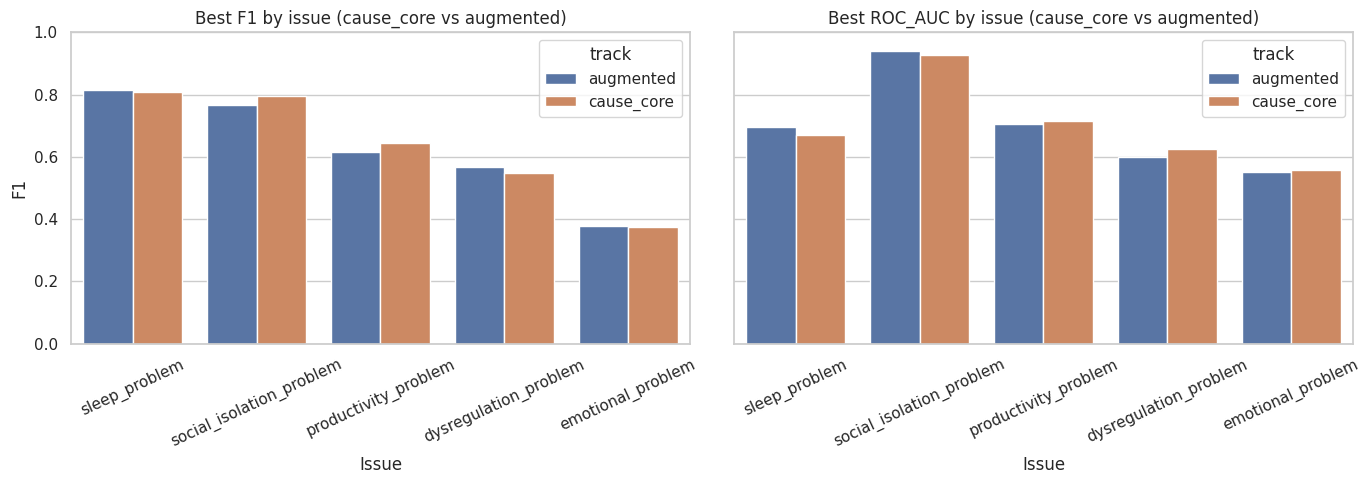

f1              roc_auc            reliability_flag           
track                    augmented cause_core augmented cause_core        augmented cause_core
issue                                                                                         
dysregulation_problem     0.567797    0.54955  0.599462   0.625729             weak       weak
emotional_problem         0.377778   0.373626  0.549678   0.558968             weak       weak
productivity_problem      0.614108   0.645669  0.703883   0.716202         reliable   reliable
sleep_problem             0.815584    0.80916  0.697021   0.671606         reliable   reliable
social_isolation_problem  0.766917   0.794118  0.939065   0.926795         reliable   reliable

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_df = issue_best_df.copy()
for i, metric in enumerate(["f1", "roc_auc"]):
    ax = axes[i]
    sns.barplot(data=plot_df, x="issue", y=metric, hue="track", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title(f"Best {metric.upper()} by issue (cause_core vs augmented)")
    ax.set_xlabel("Issue")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

issue_best_df.pivot(index="issue", columns="track", values=["f1", "roc_auc", "reliability_flag"])

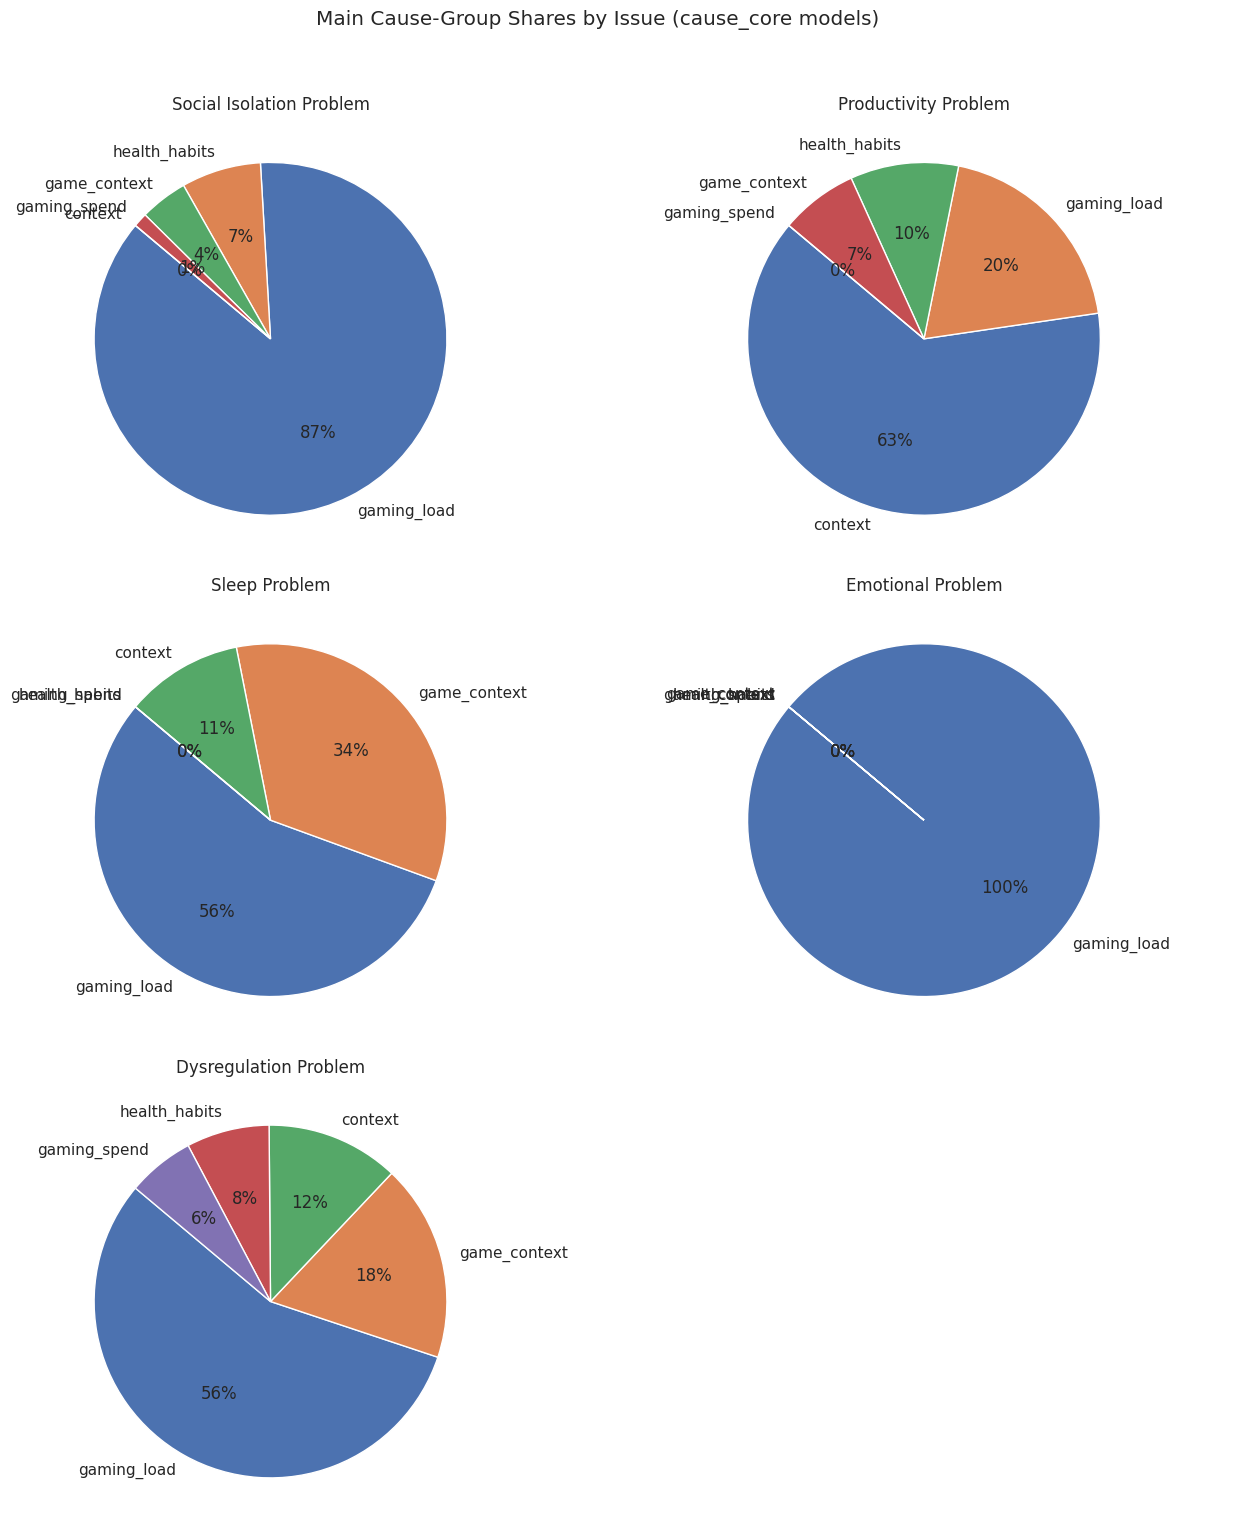

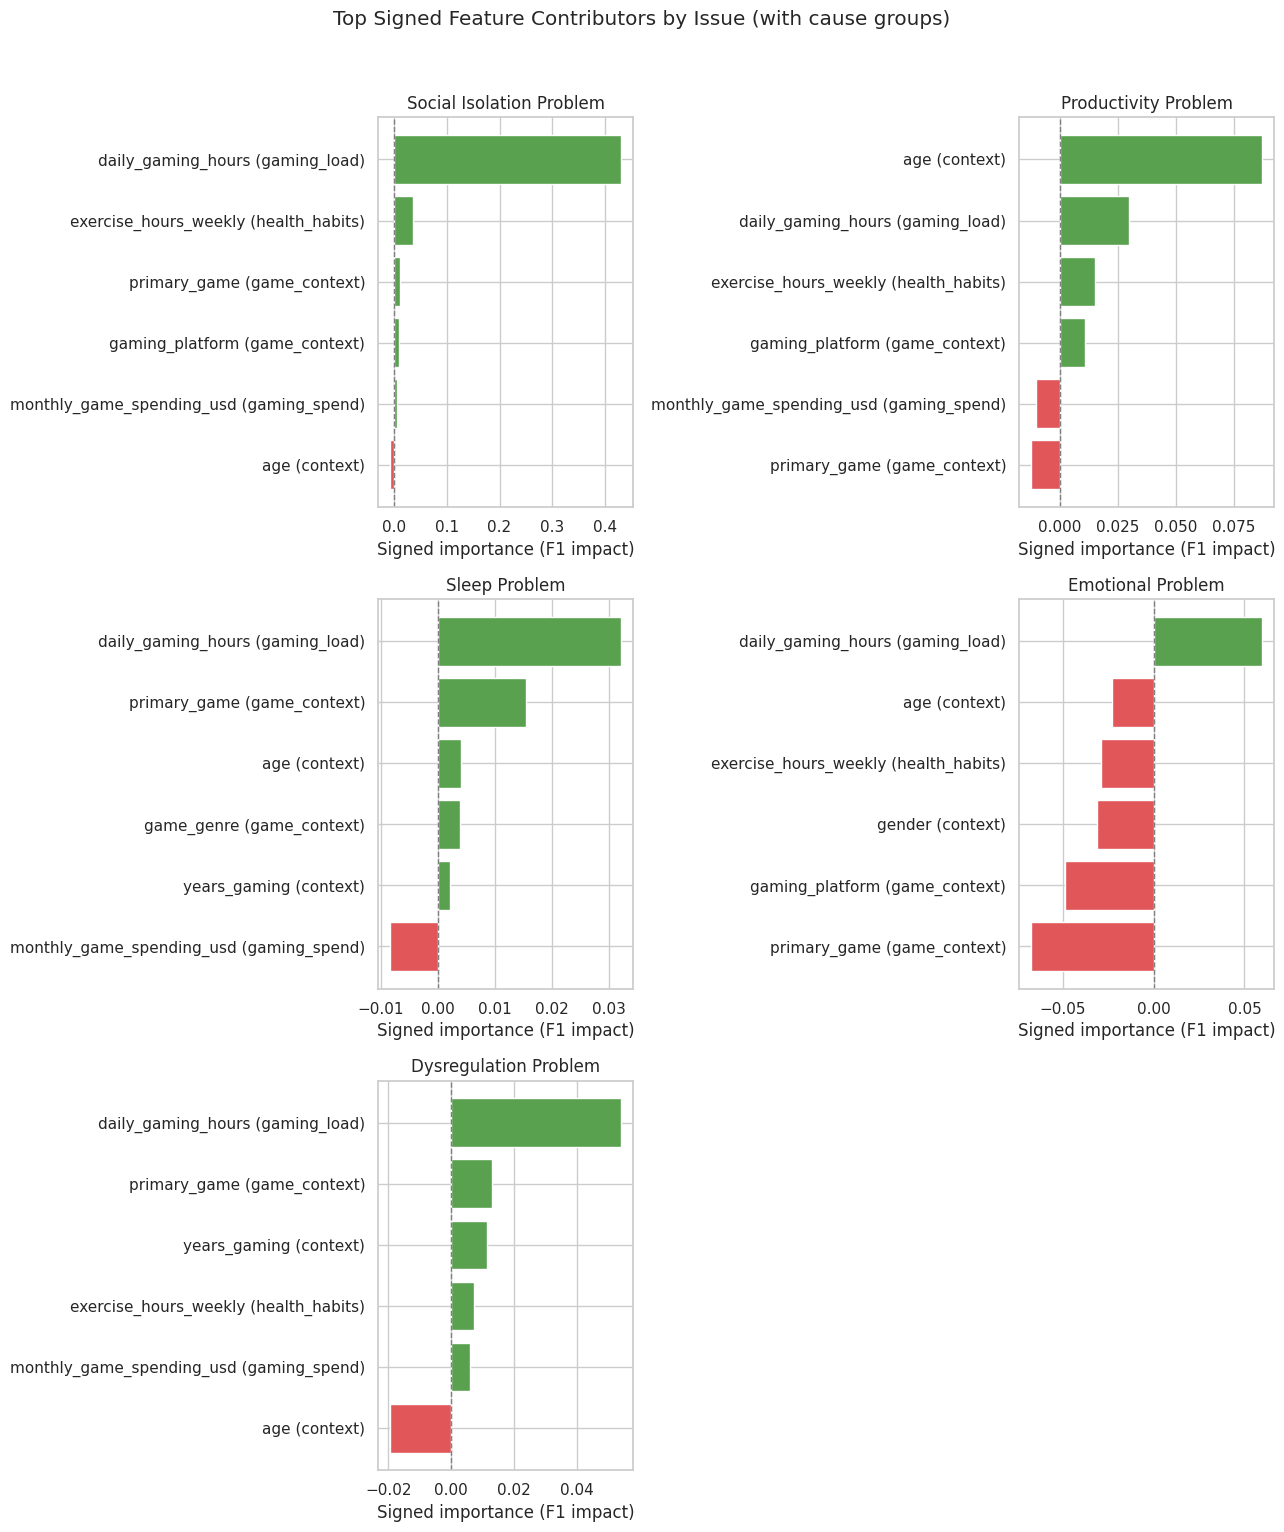

,issue,top_cause_group,top_group_share_pct
3,emotional_problem,gaming_load,100.000000
0,social_isolation_problem,gaming_load,87.024053
1,productivity_problem,context,63.442212
4,dysregulation_problem,gaming_load,55.995976
2,sleep_problem,gaming_load,55.534761


In [21]:
import math

# Cause group mapping for contributor shares.
cause_group_map = {
    "daily_gaming_hours": "gaming_load",
    "monthly_game_spending_usd": "gaming_spend",
    "exercise_hours_weekly": "health_habits",
    "game_genre": "game_context",
    "primary_game": "game_context",
    "gaming_platform": "game_context",
    "age": "context",
    "gender": "context",
    "years_gaming": "context",
    # augmented-only mediator groups (may appear if a feature enters that track)
    "sleep_hours": "sleep_process",
    "sleep_quality": "sleep_process",
    "sleep_disruption_frequency": "sleep_process",
    "mood_state": "emotion_process",
    "mood_swing_frequency": "emotion_process",
    "social_isolation_score": "social_process",
    "face_to_face_social_hours_weekly": "social_process",
    "academic_work_performance": "productivity_process",
    "work_productivity_score": "productivity_process",
}

issue_importance_tables = {}
issue_group_share_tables = {}
issue_contrib_summary_rows = []

for issue_name, pipe_i in issue_best_models.items():
    cache = issue_eval_cache[issue_name]
    perm_i = permutation_importance(
        pipe_i,
        cache["X_test"],
        cache["y_test"],
        n_repeats=10,
        random_state=RANDOM_SEED,
        scoring="f1",
        n_jobs=-1,
    )

    imp_df = pd.DataFrame({
        "feature": cache["X_test"].columns,
        "importance": perm_i.importances_mean,
    })
    imp_df["importance_abs"] = imp_df["importance"].abs()

    share_base = imp_df["importance"].clip(lower=0)
    if float(share_base.sum()) <= 1e-12:
        share_base = imp_df["importance_abs"]
    imp_df["share_base"] = share_base
    imp_df["cause_group"] = imp_df["feature"].map(cause_group_map).fillna("other")

    issue_importance_tables[issue_name] = imp_df.sort_values("importance_abs", ascending=False).reset_index(drop=True)

    grp = (
        imp_df.groupby("cause_group", as_index=False)["share_base"]
        .sum()
        .sort_values("share_base", ascending=False)
    )
    total = float(grp["share_base"].sum())
    if total <= 1e-12:
        grp["share_pct"] = 100.0 / max(len(grp), 1)
    else:
        grp["share_pct"] = 100.0 * grp["share_base"] / total

    issue_group_share_tables[issue_name] = grp

    top_group = grp.iloc[0]
    issue_contrib_summary_rows.append({
        "issue": issue_name,
        "top_cause_group": top_group["cause_group"],
        "top_group_share_pct": float(top_group["share_pct"]),
    })

issue_contrib_summary_df = pd.DataFrame(issue_contrib_summary_rows).sort_values("top_group_share_pct", ascending=False)

issues = list(issue_best_models.keys())
cols = 2
rows = math.ceil(len(issues) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, 5 * rows))
axes = np.array(axes).reshape(-1)

for idx, issue_name in enumerate(issues):
    ax = axes[idx]
    grp_df = issue_group_share_tables[issue_name].copy()

    pie_df = grp_df.head(5).copy()
    other_share = max(100.0 - float(pie_df["share_pct"].sum()), 0.0)

    labels = pie_df["cause_group"].tolist()
    values = pie_df["share_pct"].tolist()

    if other_share > 1e-9:
        labels.append("Other")
        values.append(other_share)

    ax.pie(values, labels=labels, autopct="%1.0f%%", startangle=140)
    ax.set_title(issue_name.replace("_", " ").title())

for j in range(len(issues), len(axes)):
    axes[j].axis("off")

plt.suptitle("Main Cause-Group Shares by Issue (cause_core models)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(13, 5 * rows))
axes = np.array(axes).reshape(-1)

for idx, issue_name in enumerate(issues):
    ax = axes[idx]
    imp_df = issue_importance_tables[issue_name].copy()
    top_df = imp_df.sort_values("importance_abs", ascending=False).head(6).sort_values("importance")
    colors = ["#E15759" if v < 0 else "#59A14F" for v in top_df["importance"]]

    y_labels = [f"{f} ({g})" for f, g in zip(top_df["feature"], top_df["cause_group"])]
    ax.barh(y_labels, top_df["importance"], color=colors)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(issue_name.replace("_", " ").title())
    ax.set_xlabel("Signed importance (F1 impact)")

for j in range(len(issues), len(axes)):
    axes[j].axis("off")

plt.suptitle("Top Signed Feature Contributors by Issue (with cause groups)", y=1.02)
plt.tight_layout()
plt.show()

issue_contrib_summary_df

In [22]:
if "risk_band" not in globals():
    def risk_band(p: float) -> str:
        if p < 0.20:
            return "Low"
        if p < 0.40:
            return "Moderate"
        if p < 0.60:
            return "High"
        return "Very High"

if "example_profile" not in globals():
    example_profile = {
        "age": 23,
        "gender": "Male",
        "daily_gaming_hours": 9.0,
        "game_genre": "MOBA",
        "primary_game": "League of Legends",
        "gaming_platform": "PC",
        "monthly_game_spending_usd": 110.0,
        "years_gaming": 8.0,
        "exercise_hours_weekly": 1.0,
    }


def score_profile_across_issues(profile: dict, issue_models: dict):
    rows = []
    for issue_name, pipe_i in issue_models.items():
        # Each issue can have a different feature set after leakage guards.
        feats = issue_feature_sets[issue_name]["cause_core"]
        one_row = pd.DataFrame([{c: profile.get(c, np.nan) for c in feats}])
        p = float(pipe_i.predict_proba(one_row)[:, 1][0])

        reliability = issue_best_df[(issue_best_df["issue"] == issue_name) & (issue_best_df["track"] == "cause_core")]["reliability_flag"].iloc[0]

        rows.append({
            "issue": issue_name,
            "risk_probability": p,
            "risk_band": risk_band(p),
            "model_reliability": reliability,
        })
    return pd.DataFrame(rows).sort_values("risk_probability", ascending=False).reset_index(drop=True)


def scenario_profiles(base_profile: dict):
    return {
        "baseline": {},
        "gaming_hours_-2": {"daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0.0) - 2.0)},
        "gaming_hours_-4": {"daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0.0) - 4.0)},
        "exercise_+2h": {"exercise_hours_weekly": base_profile.get("exercise_hours_weekly", 0.0) + 2.0},
        "spending_-30pct": {"monthly_game_spending_usd": max(0.0, base_profile.get("monthly_game_spending_usd", 0.0) * 0.7)},
        "combined_healthy_shift": {
            "daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0.0) - 3.0),
            "exercise_hours_weekly": base_profile.get("exercise_hours_weekly", 0.0) + 2.0,
            "monthly_game_spending_usd": max(0.0, base_profile.get("monthly_game_spending_usd", 0.0) * 0.8),
        },
    }

baseline_issue_scores = score_profile_across_issues(example_profile, issue_best_models)
print("Per-issue personal baseline risk (cause_core models):")
baseline_issue_scores

Per-issue personal baseline risk (cause_core models):


,issue,risk_probability,risk_band,model_reliability
0,social_isolation_problem,0.843117,Very High,reliable
1,productivity_problem,0.767231,Very High,reliable
2,sleep_problem,0.686410,Very High,reliable
3,dysregulation_problem,0.614163,Very High,weak
4,emotional_problem,0.602477,Very High,weak


Best scenario per issue (more negative delta is better):


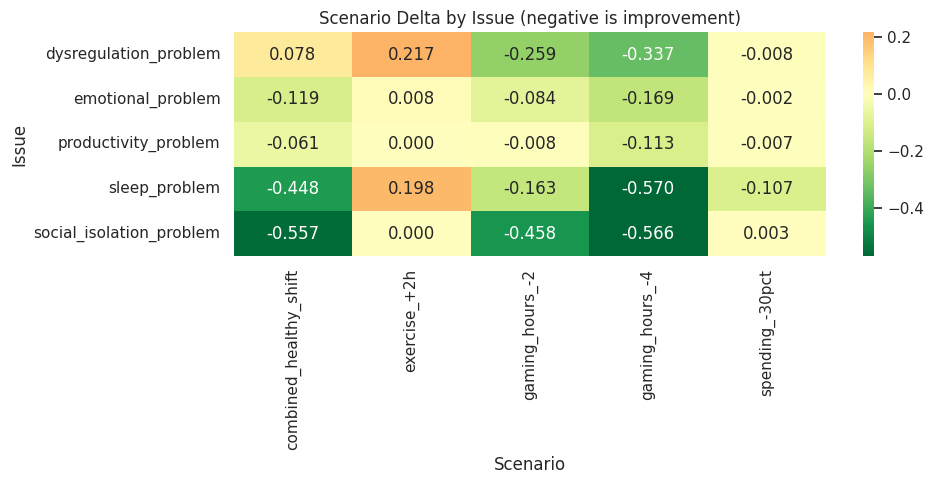

In [23]:
scenario_rows = []
for scenario_name, updates in scenario_profiles(example_profile).items():
    profile_i = dict(example_profile)
    profile_i.update(updates)
    score_df = score_profile_across_issues(profile_i, issue_best_models)
    score_df["scenario"] = scenario_name
    scenario_rows.append(score_df)

scenario_issue_df = pd.concat(scenario_rows, ignore_index=True)
baseline_map = (
    scenario_issue_df[scenario_issue_df["scenario"] == "baseline"][["issue", "risk_probability"]]
    .set_index("issue")["risk_probability"]
)
scenario_issue_df["delta_vs_baseline"] = scenario_issue_df.apply(
    lambda r: r["risk_probability"] - float(baseline_map.loc[r["issue"]]), axis=1
)

issue_reco_df = (
    scenario_issue_df[scenario_issue_df["scenario"] != "baseline"]
    .sort_values(["issue", "delta_vs_baseline"], ascending=[True, True])
    .groupby("issue", as_index=False)
    .first()
    .rename(columns={
        "scenario": "best_scenario",
        "delta_vs_baseline": "best_delta",
        "risk_probability": "post_scenario_risk",
    })
)

print("Best scenario per issue (more negative delta is better):")
issue_reco_df[["issue", "best_scenario", "best_delta", "post_scenario_risk", "model_reliability"]]

delta_pivot = (
    scenario_issue_df[scenario_issue_df["scenario"] != "baseline"]
    .pivot(index="issue", columns="scenario", values="delta_vs_baseline")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(delta_pivot, cmap="RdYlGn_r", center=0, annot=True, fmt=".3f", ax=ax)
ax.set_title("Scenario Delta by Issue (negative is improvement)")
ax.set_xlabel("Scenario")
ax.set_ylabel("Issue")
plt.tight_layout()
plt.show()

### 9.1 Personalized contributor shares by issue (cause-group view)

In [24]:
reference_numeric = {
    c: float(df[c].median()) for c in set(sum([issue_feature_sets[i]["cause_core"] for i in issue_feature_sets], [])) if pd.api.types.is_numeric_dtype(df[c])
}
reference_categorical = {
    c: str(df[c].mode().iloc[0]) for c in set(sum([issue_feature_sets[i]["cause_core"] for i in issue_feature_sets], [])) if c not in reference_numeric
}


def _local_feature_contrib_for_issue(profile: dict, issue_pipe, issue_name: str):
    feature_columns = issue_feature_sets[issue_name]["cause_core"]
    baseline_row = pd.DataFrame([{c: profile.get(c, np.nan) for c in feature_columns}])
    baseline_prob = float(issue_pipe.predict_proba(baseline_row)[:, 1][0])

    rows = []
    for feat in feature_columns:
        perturbed = dict(profile)
        if feat in reference_numeric:
            perturbed[feat] = reference_numeric[feat]
        else:
            perturbed[feat] = reference_categorical[feat]

        pert_row = pd.DataFrame([{c: perturbed.get(c, np.nan) for c in feature_columns}])
        pert_prob = float(issue_pipe.predict_proba(pert_row)[:, 1][0])
        delta = pert_prob - baseline_prob

        rows.append({
            "feature": feat,
            "cause_group": cause_group_map.get(feat, "other"),
            "baseline_prob": baseline_prob,
            "perturbed_prob": pert_prob,
            "delta": delta,
            "abs_delta": abs(delta),
        })

    out = pd.DataFrame(rows).sort_values("abs_delta", ascending=False).reset_index(drop=True)
    total = float(out["abs_delta"].sum())
    if total <= 1e-12:
        out["share_pct"] = 100.0 / len(out)
    else:
        out["share_pct"] = 100.0 * out["abs_delta"] / total
    return out


local_issue_contrib_tables = {}
local_issue_group_tables = {}
for issue_name, issue_pipe in issue_best_models.items():
    tdf = _local_feature_contrib_for_issue(example_profile, issue_pipe, issue_name)
    local_issue_contrib_tables[issue_name] = tdf

    grp = (
        tdf.groupby("cause_group", as_index=False)["abs_delta"]
        .sum()
        .sort_values("abs_delta", ascending=False)
    )
    total = float(grp["abs_delta"].sum())
    grp["share_pct"] = (100.0 * grp["abs_delta"] / total) if total > 1e-12 else (100.0 / max(len(grp), 1))
    local_issue_group_tables[issue_name] = grp

local_contrib_summary = []
for issue_name, gdf in local_issue_group_tables.items():
    top = gdf.iloc[0]
    local_contrib_summary.append({
        "issue": issue_name,
        "top_local_cause_group": top["cause_group"],
        "top_local_group_share_pct": float(top["share_pct"]),
    })

local_contrib_summary_df = pd.DataFrame(local_contrib_summary).sort_values("top_local_group_share_pct", ascending=False)
print("Top personalized cause-group contributor per issue:")
local_contrib_summary_df

Top personalized cause-group contributor per issue:


,issue,top_local_cause_group,top_local_group_share_pct
0,social_isolation_problem,gaming_load,69.379045
4,dysregulation_problem,gaming_load,68.800567
2,sleep_problem,gaming_load,61.396945
3,emotional_problem,game_context,53.918078
1,productivity_problem,context,31.148376


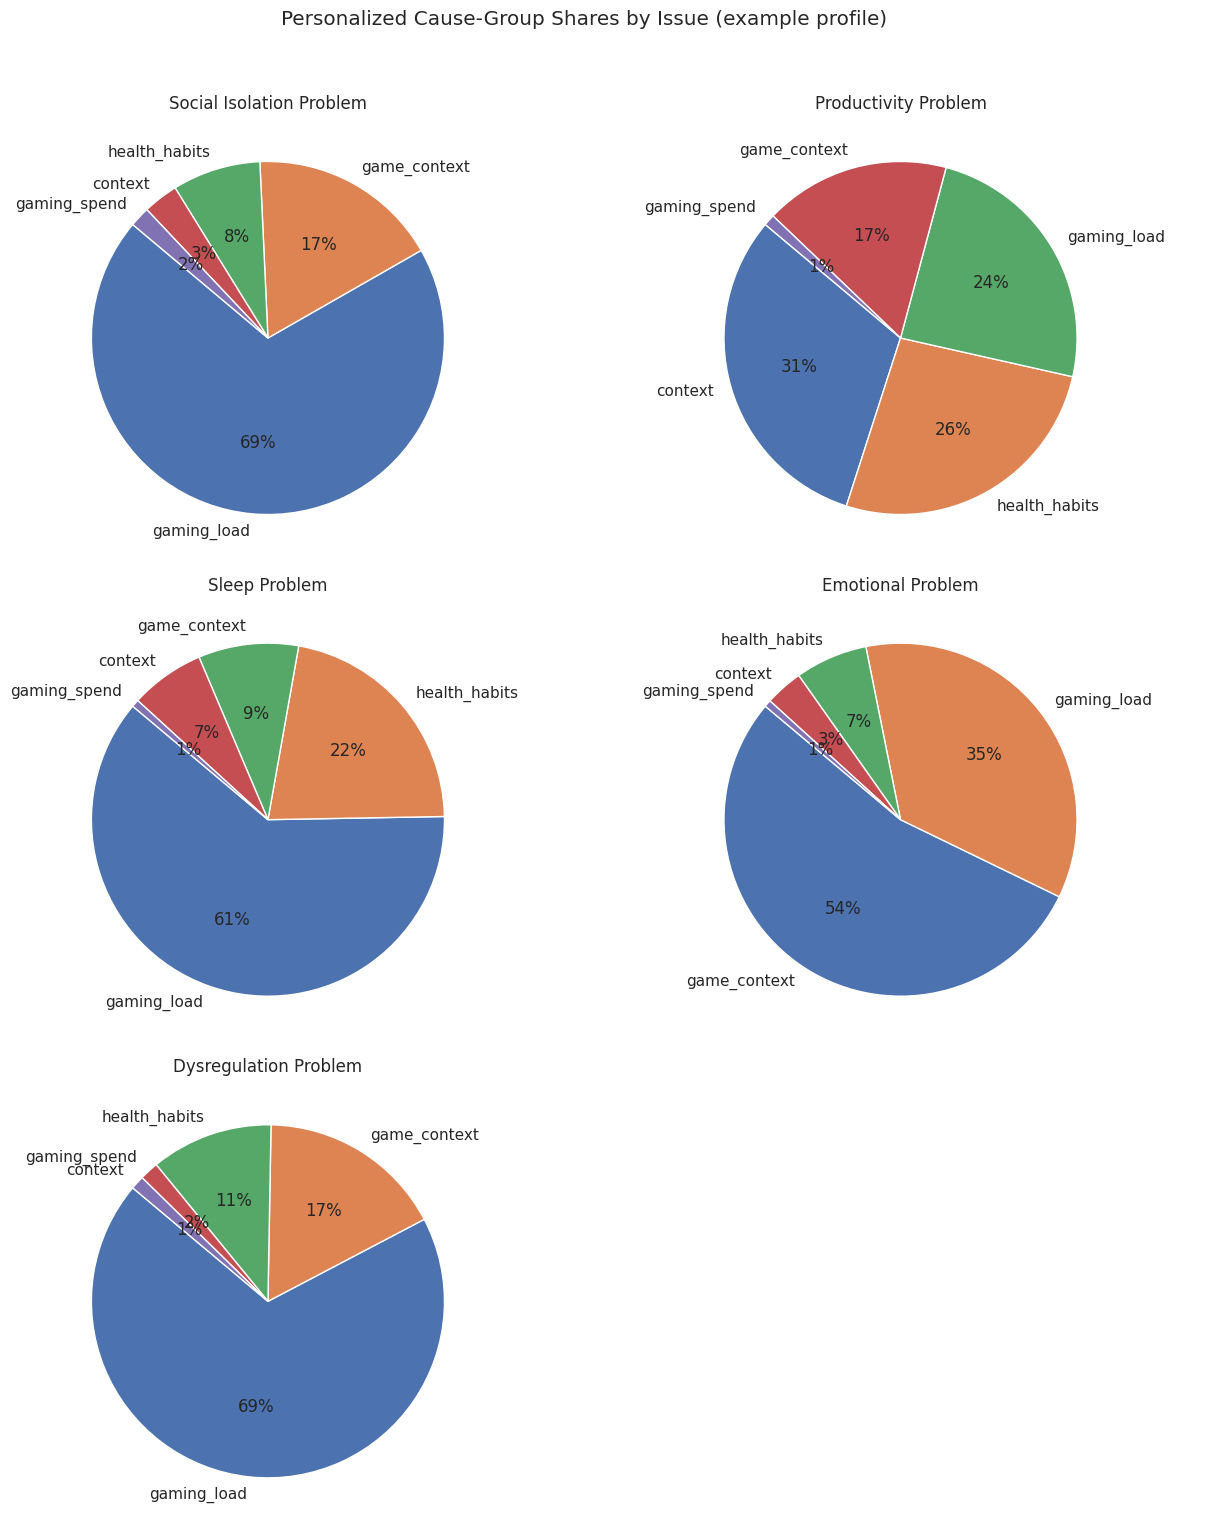

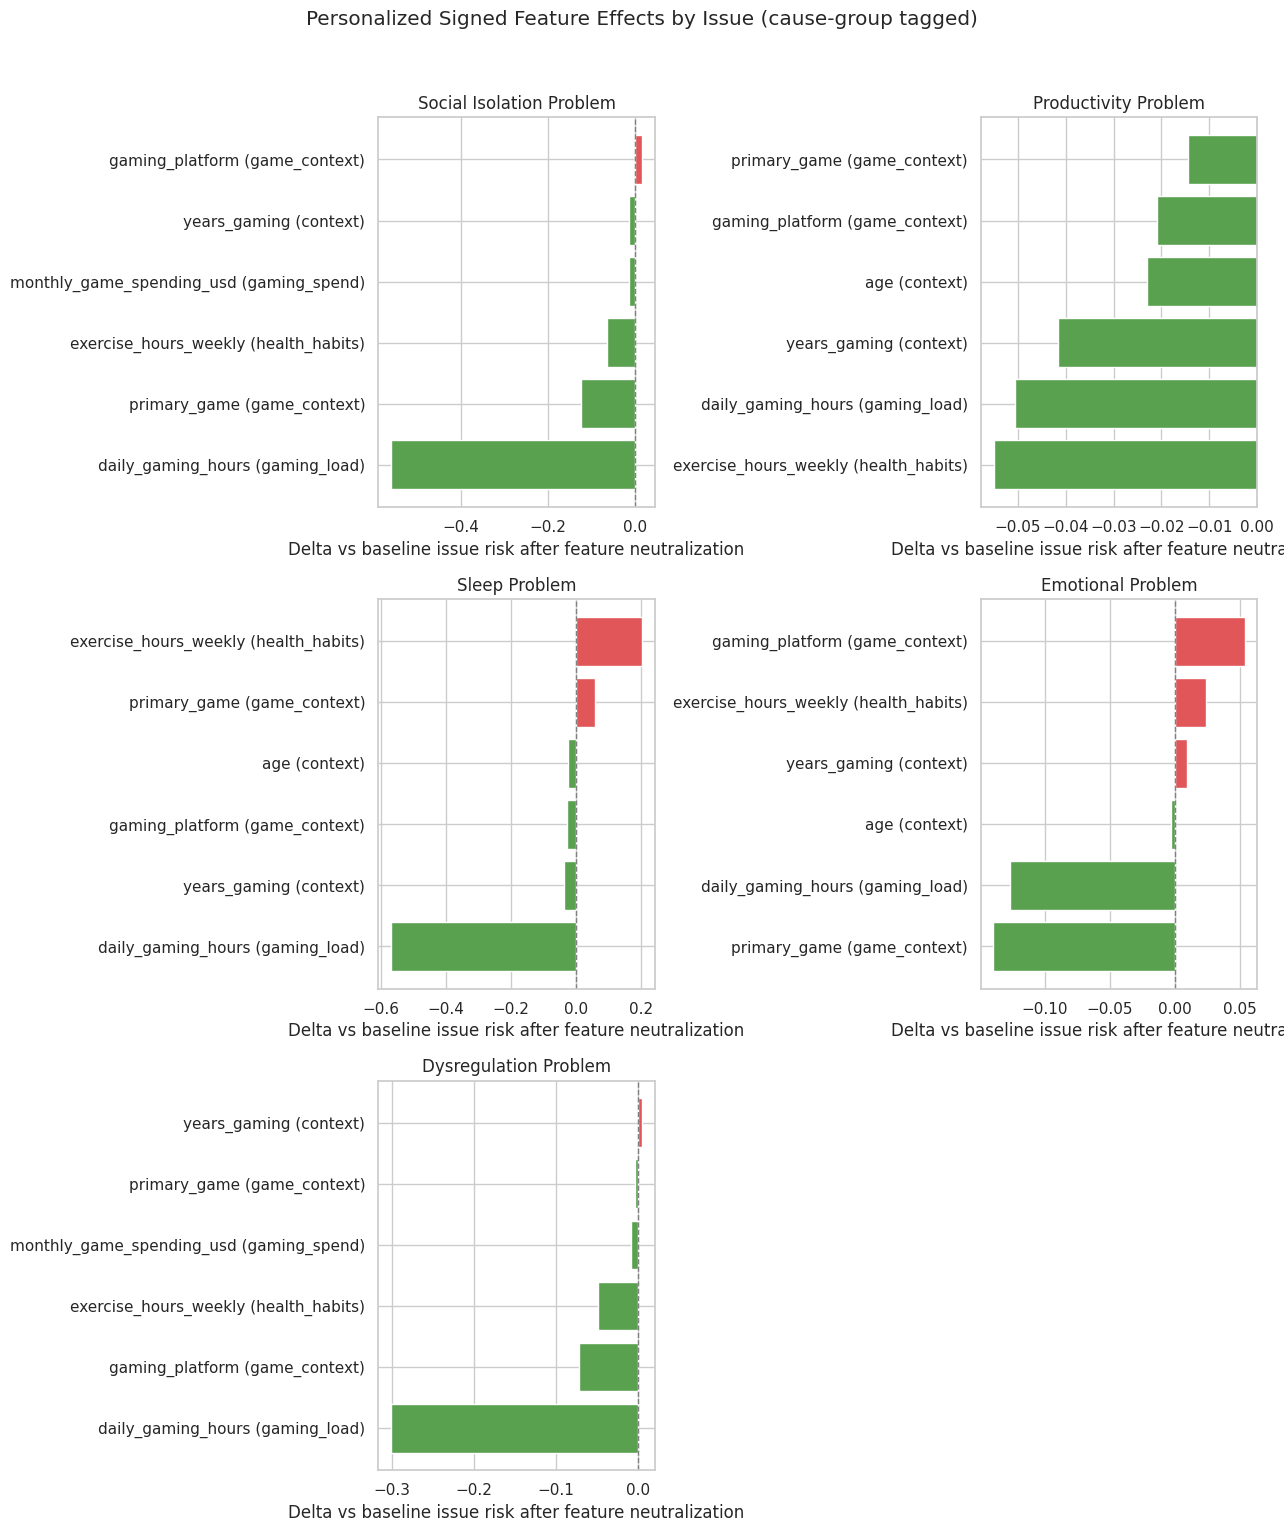

In [25]:
import math

issues_local = list(local_issue_group_tables.keys())
cols = 2
rows = math.ceil(len(issues_local) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, 5 * rows))
axes = np.array(axes).reshape(-1)

for idx, issue_name in enumerate(issues_local):
    ax = axes[idx]
    gdf = local_issue_group_tables[issue_name].copy()

    pie_df = gdf.head(5).copy()
    other_share = max(100.0 - float(pie_df["share_pct"].sum()), 0.0)

    labels = pie_df["cause_group"].tolist()
    values = pie_df["share_pct"].tolist()

    if other_share > 1e-9:
        labels.append("Other")
        values.append(other_share)

    ax.pie(values, labels=labels, autopct="%1.0f%%", startangle=140)
    ax.set_title(issue_name.replace("_", " ").title())

for j in range(len(issues_local), len(axes)):
    axes[j].axis("off")

plt.suptitle("Personalized Cause-Group Shares by Issue (example profile)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(13, 5 * rows))
axes = np.array(axes).reshape(-1)

for idx, issue_name in enumerate(issues_local):
    ax = axes[idx]
    tdf = local_issue_contrib_tables[issue_name].head(6).sort_values("delta")
    colors = ["#E15759" if x > 0 else "#59A14F" for x in tdf["delta"]]

    y_labels = [f"{f} ({g})" for f, g in zip(tdf["feature"], tdf["cause_group"])]
    ax.barh(y_labels, tdf["delta"], color=colors)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(issue_name.replace("_", " ").title())
    ax.set_xlabel("Delta vs baseline issue risk after feature neutralization")

for j in range(len(issues_local), len(axes)):
    axes[j].axis("off")

plt.suptitle("Personalized Signed Feature Effects by Issue (cause-group tagged)", y=1.02)
plt.tight_layout()
plt.show()

In [26]:
if not all(v in globals() for v in ["T", "e_hat", "Xc"]):
    raise RuntimeError("Causal prerequisites missing. Run section 6 first.")

issue_causal_rows = []

for issue_name in issue_targets.columns:
    Y_i = issue_targets[issue_name].astype(int).to_numpy()

    naive_i = float(Y_i[T == 1].mean() - Y_i[T == 0].mean())
    iptw_i = float(np.mean(T * Y_i / e_hat) - np.mean((1 - T) * Y_i / (1 - e_hat)))

    if len(np.unique(Y_i[T == 1])) < 2:
        m1_hat_i = np.full(len(Y_i), Y_i[T == 1].mean())
    else:
        m1_i = GradientBoostingClassifier(random_state=RANDOM_SEED)
        m1_i.fit(Xc[T == 1], Y_i[T == 1])
        m1_hat_i = m1_i.predict_proba(Xc)[:, 1]

    if len(np.unique(Y_i[T == 0])) < 2:
        m0_hat_i = np.full(len(Y_i), Y_i[T == 0].mean())
    else:
        m0_i = GradientBoostingClassifier(random_state=RANDOM_SEED)
        m0_i.fit(Xc[T == 0], Y_i[T == 0])
        m0_hat_i = m0_i.predict_proba(Xc)[:, 1]

    aipw_scores_i = (m1_hat_i - m0_hat_i) + (T * (Y_i - m1_hat_i) / e_hat) - ((1 - T) * (Y_i - m0_hat_i) / (1 - e_hat))
    aipw_i = float(np.mean(aipw_scores_i))
    se_i = float(np.std(aipw_scores_i, ddof=1) / np.sqrt(len(aipw_scores_i)))

    issue_causal_rows.append({
        "issue": issue_name,
        "naive_ate": naive_i,
        "iptw_ate": iptw_i,
        "aipw_ate": aipw_i,
        "ci_low": aipw_i - 1.96 * se_i,
        "ci_high": aipw_i + 1.96 * se_i,
    })

issue_causal_df = pd.DataFrame(issue_causal_rows).sort_values("aipw_ate", ascending=False).reset_index(drop=True)
issue_causal_df

,issue,naive_ate,iptw_ate,aipw_ate,ci_low,ci_high
0,social_isolation_problem,0.714667,0.192740,0.465633,0.431633,0.499632
1,sleep_problem,0.244000,-0.298153,0.329498,0.290173,0.368823
2,dysregulation_problem,0.242667,-0.152400,0.235625,0.187189,0.284061
3,productivity_problem,0.205333,-0.164383,0.181615,0.134896,0.228334
4,emotional_problem,0.137333,-0.135776,-0.057713,-0.101658,-0.013768


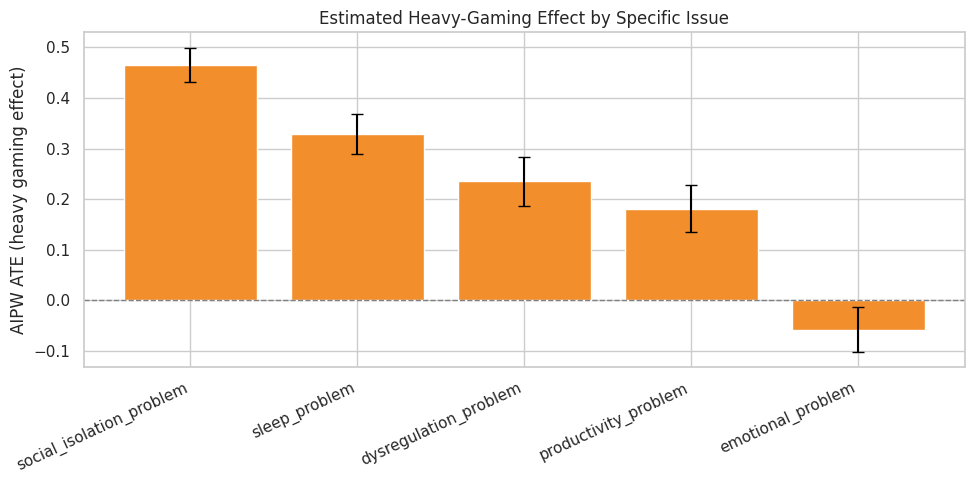

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(issue_causal_df["issue"], issue_causal_df["aipw_ate"], color="#F28E2B")
ax.errorbar(
    x=np.arange(len(issue_causal_df)),
    y=issue_causal_df["aipw_ate"],
    yerr=[issue_causal_df["aipw_ate"] - issue_causal_df["ci_low"], issue_causal_df["ci_high"] - issue_causal_df["aipw_ate"]],
    fmt="none",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(issue_causal_df)))
ax.set_xticklabels(issue_causal_df["issue"], rotation=25, ha="right")
ax.set_ylabel("AIPW ATE (heavy gaming effect)")
ax.set_title("Estimated Heavy-Gaming Effect by Specific Issue")
plt.tight_layout()
plt.show()

In [28]:
most_risky_issue = baseline_issue_scores.iloc[0]
most_causal_issue = issue_causal_df.iloc[0]

print("=== Issue-level summary for actionability ===")
print(f"Highest personal issue risk: {most_risky_issue['issue']} (p={most_risky_issue['risk_probability']:.3f}, band={most_risky_issue['risk_band']})")
print(f"Largest adjusted heavy-gaming effect: {most_causal_issue['issue']} (AIPW={most_causal_issue['aipw_ate']:.3f})")

print("\nRecommended usage:")
print("1) Use per-issue probabilities to prioritize which wellbeing domain to target first.")
print("2) Use contributor pie charts to identify the dominant drivers for each issue.")
print("3) Use scenario deltas to choose behavior changes with the strongest expected risk reduction.")
print("4) Re-score weekly and track trend direction, not single-day noise.")

=== Issue-level summary for actionability ===
Highest personal issue risk: social_isolation_problem (p=0.843, band=Very High)
Largest adjusted heavy-gaming effect: social_isolation_problem (AIPW=0.466)

Recommended usage:
1) Use per-issue probabilities to prioritize which wellbeing domain to target first.
2) Use contributor pie charts to identify the dominant drivers for each issue.
3) Use scenario deltas to choose behavior changes with the strongest expected risk reduction.
4) Re-score weekly and track trend direction, not single-day noise.


## 7) Interpretation (grouped cause → issue framing)

In [29]:
best_row = results_df.iloc[0].to_dict()

chosen_for_export = str(best_model_name)

print("Overall model summary:")
print(
    f"- Best overall model: {best_model_name} | "
    f"F1={best_row['f1']:.3f}, ROC-AUC={best_row['roc_auc']:.3f}, "
    f"Accuracy={best_row['accuracy']:.3f}"
)

print("\nCause→issue interpretation notes:")
print("- Use cause_core issue models for recommendations (most intervention-aligned).")
print("- Augmented models can improve prediction but may be less intervention-transparent.")
print("- Reliability flags identify issues where model outputs should be treated cautiously.")
print("- Personalized shares indicate likely contributors for the specific profile, not universal truth.")

weak_issues = issue_best_df[
    (issue_best_df["track"] == "cause_core") & (issue_best_df["reliability_flag"] == "weak")
]["issue"].tolist()
if weak_issues:
    print(f"- Weak cause_core issue models (ROC-AUC < {ISSUE_RELIABILITY_ROC_THRESHOLD:.2f}): {weak_issues}")

final_payload = {
    "best_model": chosen_for_export,
    "best_metrics": {
        "accuracy": float(best_row["accuracy"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row["roc_auc"]),
    },
    "target_prevalence": float(df["wellbeing_problem"].mean()),
    "top_features": perm_df["feature"].head(5).tolist(),
    "heavy_gaming_threshold_hours": float(treatment_threshold),
    "heavy_gaming_rate": float(df["heavy_gaming"].mean()),
    "causal_effects": {
        "naive_ate": float(naive_ate),
        "iptw_ate": float(iptw_ate),
        "aipw_ate": float(aipw_ate),
        "aipw_ci_low": float(aipw_ci[0]),
        "aipw_ci_high": float(aipw_ci[1]),
    },
    "issue_best_models": issue_best_df[["issue", "track", "model", "f1", "roc_auc", "reliability_flag"]].to_dict(orient="records"),
    "issue_top_cause_groups": issue_contrib_summary_df.to_dict(orient="records"),
    "personalized_top_groups": local_contrib_summary_df.to_dict(orient="records"),
}

print("\nFINAL_RESULTS_JSON=" + json.dumps(final_payload, sort_keys=True))

Overall model summary:
- Best overall model: GradientBoosting | F1=0.686, ROC-AUC=0.900, Accuracy=0.824

Cause→issue interpretation notes:
- Use cause_core issue models for recommendations (most intervention-aligned).
- Augmented models can improve prediction but may be less intervention-transparent.
- Reliability flags identify issues where model outputs should be treated cautiously.
- Personalized shares indicate likely contributors for the specific profile, not universal truth.
- Weak cause_core issue models (ROC-AUC < 0.65): ['dysregulation_problem', 'emotional_problem']

FINAL_RESULTS_JSON={"best_metrics": {"accuracy": 0.824, "f1": 0.6857142857142857, "precision": 0.6666666666666666, "recall": 0.7058823529411765, "roc_auc": 0.9002908855850033}, "best_model": "GradientBoosting", "causal_effects": {"aipw_ate": 0.16339597122904492, "aipw_ci_high": 0.20173503137472903, "aipw_ci_low": 0.1250569110833608, "iptw_ate": 0.09838623048329437, "naive_ate": 0.5773333333333333}, "heavy_gaming_r